# Q2 — Unsupervised Learning: Customer Segmentation

## Objective
Perform customer segmentation using K-Means clustering and visualize the clusters using PCA.

## Why Scaling is Important for K-Means

K-Means relies on distance-based calculations (Euclidean distance).  
If features are on different scales (e.g., annual_spend in thousands vs visits_per_month in tens), features with larger values dominate the clustering process.

Scaling ensures:
- All features contribute equally
- Clusters are meaningful and not biased
- Faster convergence of the K-Means algorithm

Therefore, we use **StandardScaler** to standardize all features.

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("q2_customers.csv")

print("Shape:", df.shape)
df.head()

Shape: (500, 6)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
# Scale features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


2. Choosing K — Elbow Method

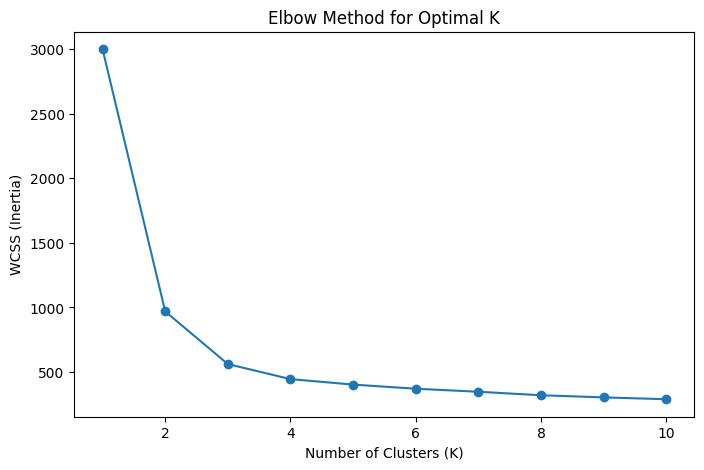

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Compute WCSS for K = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot Elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.show()


## Elbow Method Interpretation

The elbow graph shows a sharp decrease in WCSS initially, which then starts to level off.

The “elbow point” represents the optimal number of clusters, where adding more clusters does not significantly reduce WCSS.

From the plot:
- The curve begins to flatten around **K = 4**
- This indicates diminishing returns beyond this point

Therefore, the optimal number of clusters chosen is **K = 4**

3. K-Means Clustering

In [4]:
# Fit KMeans with chosen K
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_df)

# Add cluster column
df["cluster"] = clusters

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [5]:
# Convert centroids back to original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=df.columns[:-1])

print("Cluster Centroids:")
centroid_df

Cluster Centroids:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,57.037500,89814.075000,2.462500,5296.362500,148.000000,7.487500
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,56.517647,89036.164706,2.588235,5750.952941,65.223529,7.541176


## Cluster Interpretation (Business View)

Based on centroid values:

### Cluster 0:
Customers with moderate age, moderate spend, and regular visits.
Represents **average / balanced customers**

### Cluster 1:
Young customers with high visit frequency but low spending and small basket size.
Represents **frequent low-value shoppers**

### Cluster 2:
Older customers with very high spend, large basket size, and infrequent visits.
Represents **premium / high-value customers**

### Cluster 3:
Customers with lower visits and moderate-to-high basket sizes but long inactivity periods.
Represents **at-risk / churn-prone customers**

These insights help in:
- Targeted marketing
- Personalised offers
- Retention strategies

4. PCA

In [6]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])
pca_df["cluster"] = clusters

pca_df.head()


,PC1,PC2,cluster
0,-0.333082,0.109379,2
1,-2.255362,0.048458,0
2,-0.092905,-0.679257,2
3,-2.017598,-0.308845,0
4,-2.917762,0.529368,0


In [7]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.83560354 0.05568764]


In [12]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=["PC1", "PC2"]
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


## PCA Interpretation

### PC1:
PC1 captures overall customer value:
- High influence from **annual_spend, basket_size, num_categories_purchased**
Represents **customer spending power / value**

### PC2:
PC2 is influenced by:
- **visits_per_month and days_since_last_visit**
Represents **customer engagement / activity**

Thus:
- PC1 → Value dimension
- PC2 → Activity dimension

5. Cluster Visualization

Text(0, 0.5, 'Principal Component 2')

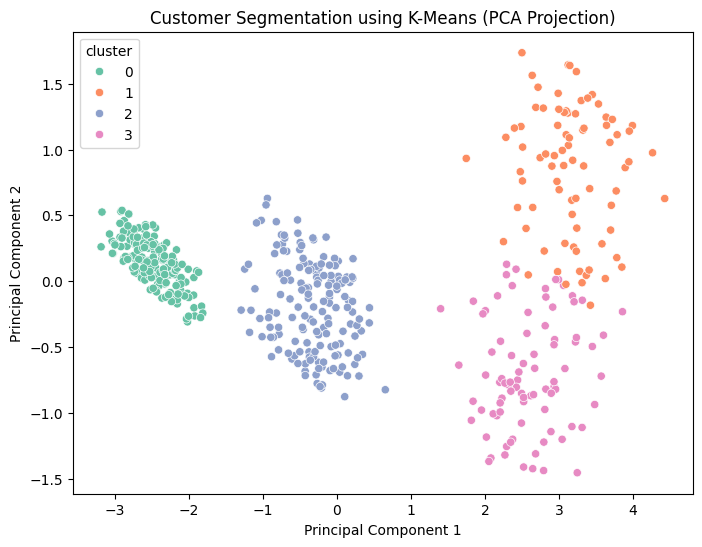

In [10]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2'
)

plt.title("Customer Segmentation using K-Means (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
